# Drill-02 — 워드클라우드 실습

**총점**: 100점 (4문제 × 25점)

---

### ⚠️ 주의사항

1. 아래 **Setup** 셀을 **가장 먼저** 실행하세요 (`Shift + Enter`).
2. `# ===코드 시작===` 과 `# ===코드 종료===` **사이에** 코드를 작성하세요.
3. 기존 셀을 **삭제하지 마세요**. 삭제하면 채점이 안 됩니다.
4. 모든 결과는 `print()` 함수로 출력해야 합니다.
5. 파일명을 `학번_이름.ipynb` 형식으로 변경 후 제출하세요.
6. 셀은 **위에서 아래로 순서대로** 실행하세요. 각 문제는 이전 문제의 변수를 이어서 사용합니다.

In [1]:
import pandas as pd
import re
from pecab import PeCab
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import koreanize_matplotlib
import matplotlib.font_manager as fm
from collections import Counter

# koreanize_matplotlib이 설정한 한글 폰트 경로를 WordCloud에 재사용
FONT_PATH = fm.findfont(plt.rcParams['font.family'][0])


> **Q01** (25점)
>
> `corpus_가천대.csv`를 `pd.read_csv()`로 불러와 **`df`** 변수에 저장하세요. 다음 두 줄을 그대로 실행하세요:
>
> `print(df.shape)`
>
> `print(df.head(3))`


In [2]:
# ===코드 시작===
# 코드를 작성하세요
import pandas as pd

df = pd.read_csv("corpus_가천대.csv", encoding="utf-8")

print(df.shape)
print(df.head(3))

# ===코드 종료===

(10, 5)
                              title  \
0       가천대, 베트남 CIED와 글로벌 인재 양성 협약   
1  가천대, AI 아이케어 키오스크 공개…산학협력 사업화 성과   
2         인천 남동구에 ‘가천이길여길’ 명예도로명 부여   

                                             content      source        date  \
0  [가천대 제공] [헤럴드경제(성남)=박정규 기자]가천대(총장 이길여)가 지난 25일...  heraldcorp  2026-03-26   
1  바이오헬스 GUIP사업단 나라장터 엑스포 참가 전문가 얼라이언스 활용…기업 맞춤형 ...         unn         NaN   
2  [이데일리 이순용 의학전문기자] 가천대 길병원이 위치한 인천광역시 남동구에 설립자 ...      edaily         NaN   

                                                 url  
0  https://biz.heraldcorp.com/article/10703732?re...  
1  https://news.unn.net/news/articleView.html?idx...  
2  http://www.edaily.co.kr/news/newspath.asp?news...  


> **Q02** (25점)
> 💡 **힌트**: `re.sub(r'[^가-힣 ]', ' ', text)` 사용

>
> **Q01에서 만든 `df`**를 사용하세요.
>
> 1. `df['content']` 컬럼의 텍스트를 모두 하나의 문자열로 합쳐 **`text`** 변수에 저장하세요.
>    (결측값은 `.dropna()`로 제거 후 합치세요.)
> 2. 한글(가-힣)과 공백 이외의 모든 문자를 제거해 **`text`**를 갱신하세요.
> 3. 불용어 `['가천대', '총장', '이길여', '대학교']`를 각각 공백으로 치환해 **`text`**를 갱신하세요.
> 4. `re.sub(r'\s+', ' ', text).strip()`으로 연속 공백을 정리하고 **`text`**에 저장하세요.
> 5. `print(text[:200])`을 실행하세요.


In [3]:
# ===코드 시작===
# 코드를 작성하세요
text = " ".join(df["content"].dropna().astype(str))

text = re.sub(r'[^가-힣 ]', ' ', text)

stopwords = ["가천대", "총장", "이길여", "대학교"]
for word in stopwords:
    text = text.replace(word, " ")

text = re.sub(r'\s+', ' ', text).strip()

print(text[:200])

# ===코드 종료===

제공 헤럴드경제 성남 박정규 기자 가 지난 일 베트남 교육부 산하 기관 와 글로벌 인재 양성을 위한 업무협약 을 체결했다 는 베트남 교육부 산하 기관으로 해외 유학 지원 국제 교육 프로그램 운영 글로벌 교육 네트워크 구축 등을 담당하며 베트남 교육의 국제화를 선도하고 있다 협약식은 이날 글로벌센터에서 열렸으며 김상혁 국제교류처장과 판 탄 빈 부센터장 등 양


> **Q03** (25점)
>
> **Q02에서 만든 `text`**를 사용하세요.
> ⚠️ pecab은 긴 텍스트에서 매우 느리므로 반드시 **`text[:500]`**만 사용하세요.
>
> 1. `text[:500]`에서 명사를 추출해 **`nouns`** 변수에 저장하세요.
> 2. 명사 빈도를 집계해 **`counter`** 변수에 저장하세요.
> 3. `print(counter.most_common(10))`을 실행하세요.


In [4]:
# ===코드 시작===
# 코드를 작성하세요
pecab = PeCab()
nouns = pecab.nouns(text[:500])

counter = Counter(nouns)

print(counter.most_common(10))

# ===코드 종료===

c:\Users\kik32\workspace\unstructured-data-processing\.venv\Lib\site-packages\pecab\_tokenizer.py:265: RuntimeWarning: overflow encountered in scalar add
  from_pos_data.costs[idx]
c:\Users\kik32\workspace\unstructured-data-processing\.venv\Lib\site-packages\pecab\_tokenizer.py:274: RuntimeWarning: overflow encountered in scalar add
  least_cost += word_cost


[('교육', 9), ('베트남', 6), ('글로벌', 4), ('협약', 4), ('국제', 4), ('기관', 3), ('지원', 3), ('등', 3), ('교류', 3), ('협력', 3)]


> **Q04** (25점)
>
> **Q03에서 만든 `nouns`**를 사용하세요.
>
> 1. `nouns`를 하나의 문자열로 합쳐 **`noun_text`** 변수에 저장하세요.
> 2. `noun_text`로 워드클라우드를 생성해 **`wc`** 변수에 저장하세요.
>    ⚠️ 한글이 표시되려면 `font_path=FONT_PATH`를 **반드시** 포함하세요:
>    `wc = WordCloud(font_path=FONT_PATH, ...).generate(noun_text)`
> 3. 아래 코드를 **그대로** 실행하세요:
>    ```python
>    plt.figure(figsize=(10, 5))
>    plt.imshow(wc, interpolation='bilinear')
>    plt.axis('off')
>    plt.show()
>    ```
> 4. `print(f'명사 {len(nouns)}개로 워드클라우드 생성 완료')`를 실행하세요.


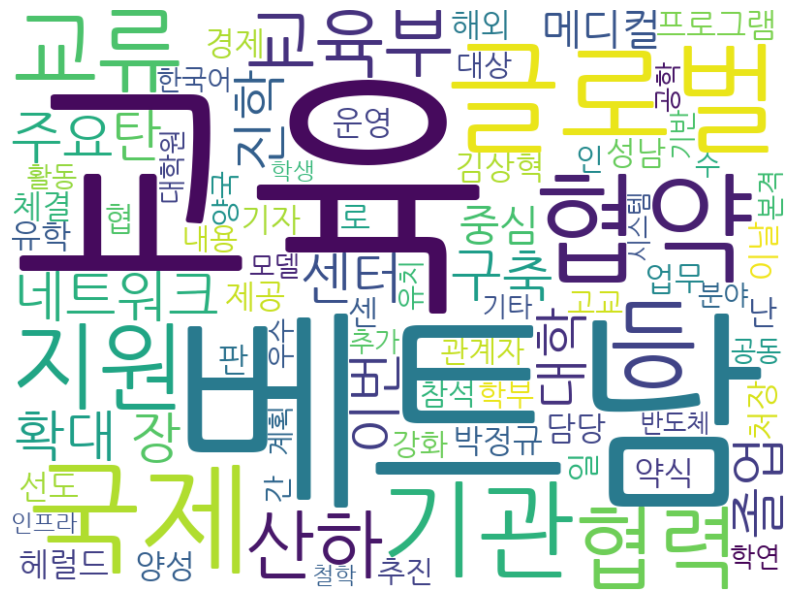

명사 129개로 워드클라우드 생성 완료


In [5]:
# ===코드 시작===
# 코드를 작성하세요
noun_text = " ".join(nouns)

wc = WordCloud(
  font_path=FONT_PATH,
  width=800,
  height=600,
  background_color="white"
).generate(noun_text)

plt.figure(figsize=(10, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

print(f'명사 {len(nouns)}개로 워드클라우드 생성 완료')

# ===코드 종료===